# California Housing Price Prediction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [8]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [9]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20433, dtype: float64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
train_df=X_train.join(y_train)

In [14]:
train_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
17727,-121.80,37.32,14.0,4412.0,924.0,2698.0,891.0,4.7027,<1H OCEAN,227600.0
2057,-119.63,36.64,33.0,1036.0,181.0,620.0,174.0,3.4107,INLAND,110400.0
6453,-118.06,34.12,25.0,3891.0,848.0,1848.0,759.0,3.6639,INLAND,248100.0
4619,-118.31,34.07,28.0,2362.0,949.0,2759.0,894.0,2.2364,<1H OCEAN,305600.0
15266,-117.27,33.04,27.0,1839.0,392.0,1302.0,404.0,3.5500,NEAR OCEAN,214600.0
...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24.0,2991.0,500.0,1437.0,453.0,5.4286,<1H OCEAN,273400.0
12081,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,<1H OCEAN,160800.0
5447,-118.42,34.01,42.0,1594.0,369.0,952.0,362.0,3.0990,<1H OCEAN,335400.0
866,-122.04,37.57,12.0,5719.0,1064.0,3436.0,1057.0,5.2879,NEAR BAY,231200.0


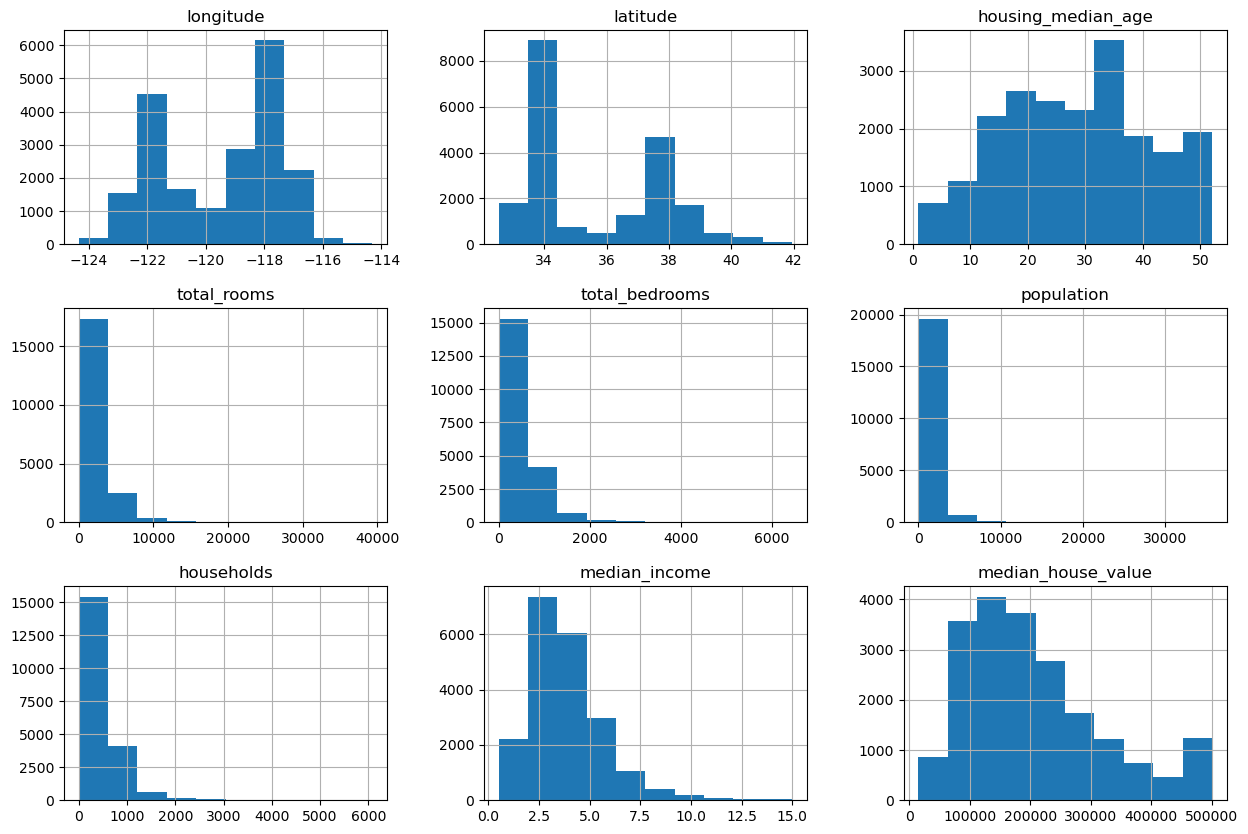

In [15]:
df.hist(figsize=(15,10))
plt.show()

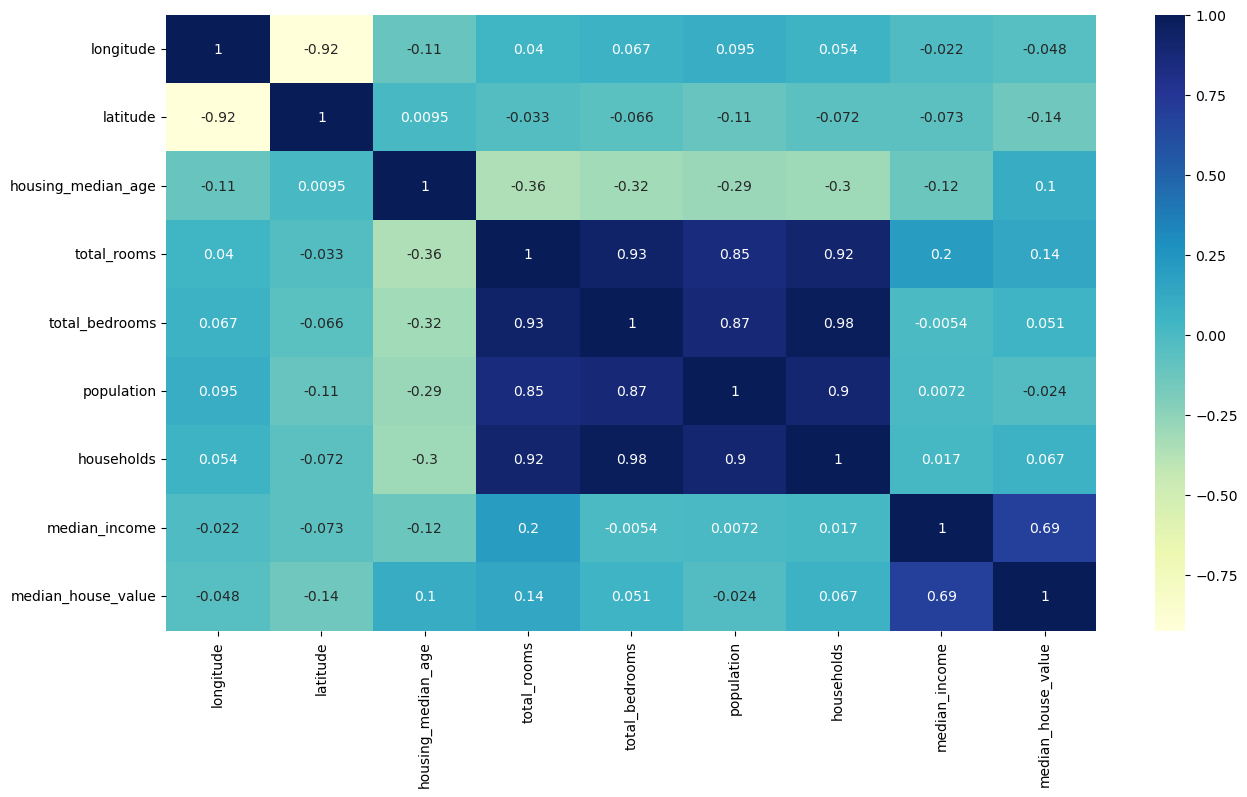

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(
    train_df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="YlGnBu"
)
plt.show()

In [17]:
train_df["total_rooms"] = np.log(train_df["total_rooms"] + 1)
test_df["total_rooms"] = np.log(test_df["total_rooms"] + 1)

train_df["total_bedrooms"] = np.log(train_df["total_bedrooms"] + 1)
test_df["total_bedrooms"] = np.log(test_df["total_bedrooms"] + 1)

train_df["population"] = np.log(train_df["population"] + 1)
test_df["population"] = np.log(test_df["population"] + 1)

train_df["households"] = np.log(train_df["households"] + 1)
test_df["households"] = np.log(test_df["households"] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

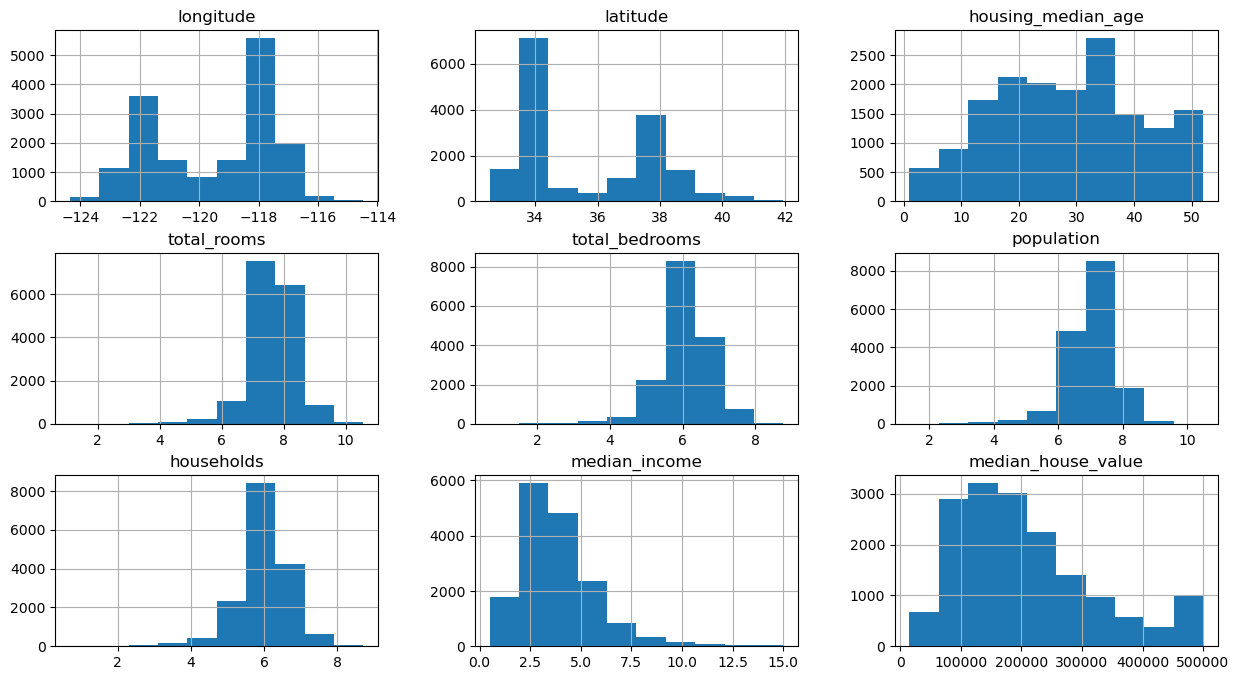

In [18]:
train_df.hist(figsize=(15,8))

In [19]:
train_df = train_df.join(
    pd.get_dummies(train_df.ocean_proximity)
).drop("ocean_proximity", axis=1)

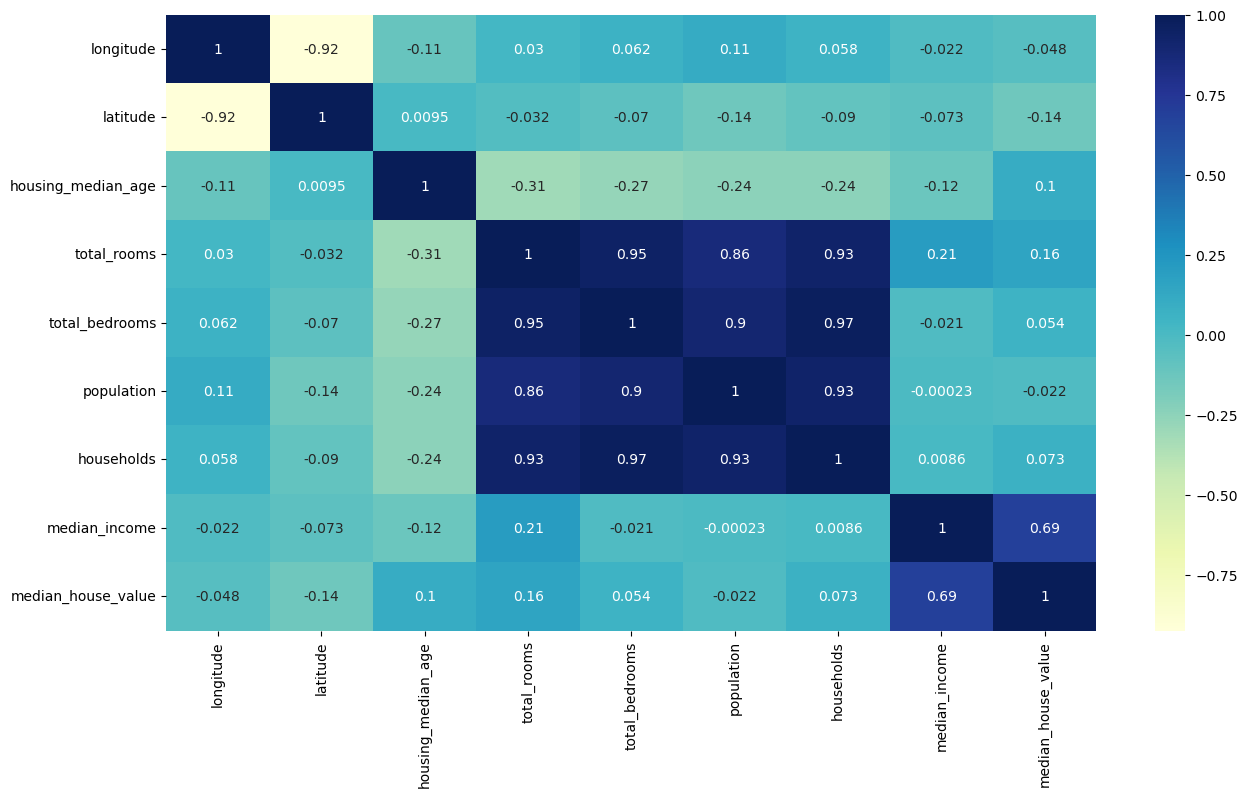

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(
    train_df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="YlGnBu"
)
plt.show()

In [21]:
train_df["rooms_per_household"] = (
    train_df["total_rooms"] /
    train_df["households"]
)

test_df["rooms_per_household"] = (
    test_df["total_rooms"] /
    test_df["households"]
)


train_df["bedrooms_per_room"] = (
    train_df["total_bedrooms"] /
    train_df["total_rooms"]
)

test_df["bedrooms_per_room"] = (
    test_df["total_bedrooms"] /
    test_df["total_rooms"]
)


train_df["population_per_household"] = (
    train_df["population"] /
    train_df["households"]
)

test_df["population_per_household"] = (
    test_df["population"] /
    test_df["households"]
)

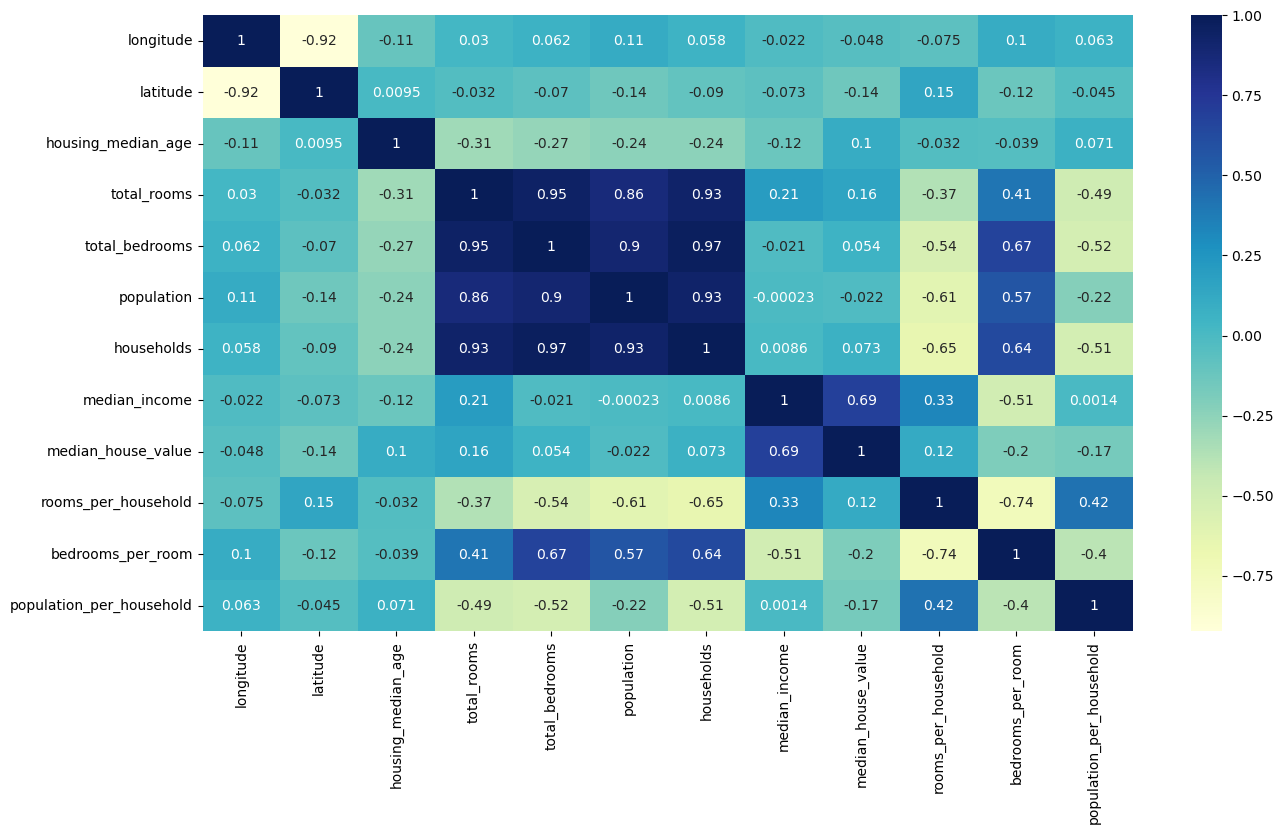

In [22]:
plt.figure(figsize=(15,8))
sns.heatmap(
    train_df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="YlGnBu"
)
plt.show()

In [ ]:
train_df = train_df.join(
    pd.get_dummies(
        train_df["ocean_proximity"],
        dtype=int
    )
)

In [ ]:
train_df = train_df.drop(
    "ocean_proximity",
    axis=1
)

In [23]:
test_df = test_df.join(
    pd.get_dummies(
        test_df["ocean_proximity"],
        dtype=int
    )
)

In [24]:
test_df = test_df.drop(
    "ocean_proximity",
    axis=1
)

In [25]:
train_df, test_df = train_df.align(
    test_df,
    join="left",
    axis=1,
    fill_value=0
)

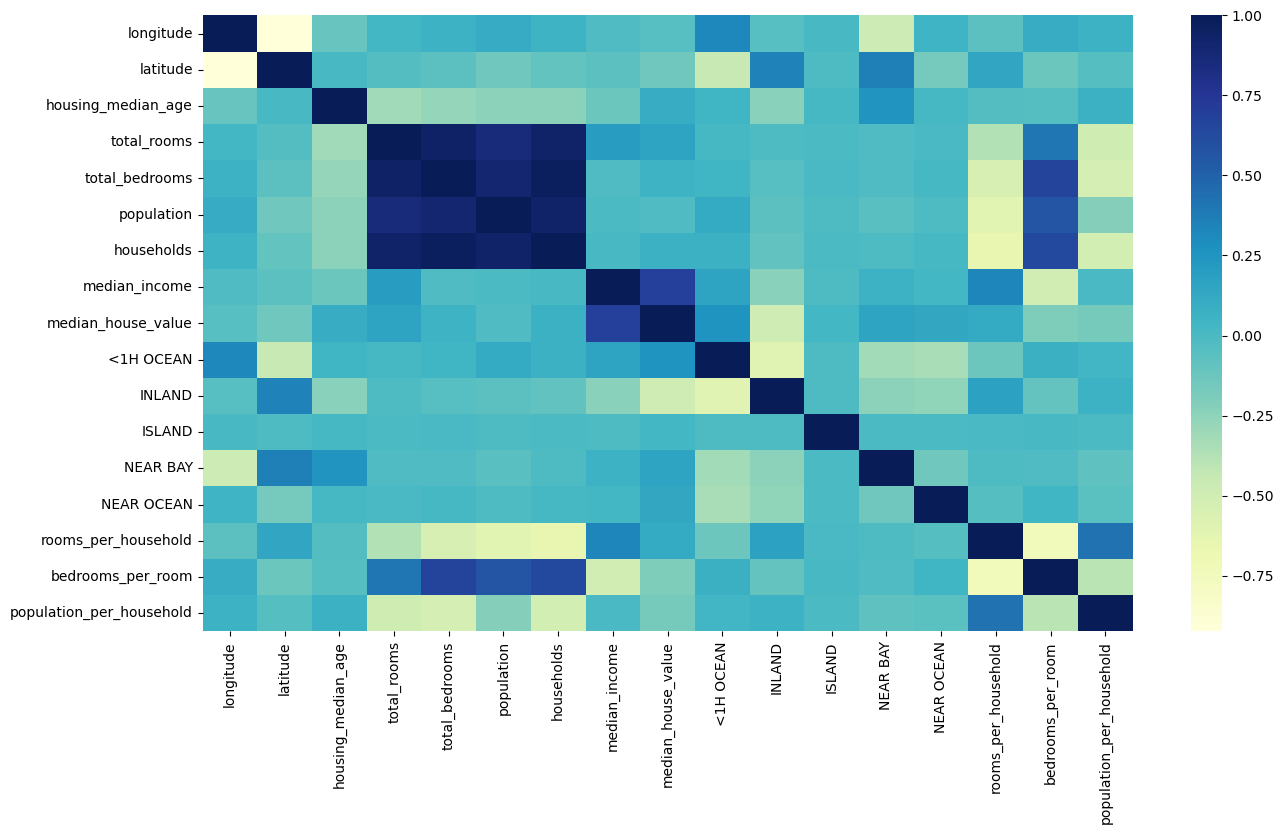

In [26]:
plt.figure(figsize=(15,8))

sns.heatmap(
    train_df.corr(),
    cmap="YlGnBu"
)

plt.show()

In [27]:
X_train = train_df.drop(
    "median_house_value",
    axis=1
)

y_train = train_df["median_house_value"]

In [28]:
X_test = test_df.drop(
    "median_house_value",
    axis=1
)

y_test = test_df["median_house_value"]

In [29]:
scaler = StandardScaler()

In [30]:
X_train_scaled = scaler.fit_transform(
    X_train
)

In [31]:
X_test_scaled = scaler.transform(
    X_test
)

In [32]:
lr = LinearRegression()

In [33]:
lr.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
lr.score(
    X_test_scaled,
    y_test
)

0.6710714692701566

In [35]:
rf = RandomForestRegressor(
    random_state=42
)

In [36]:
rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf.score(
    X_test,
    y_test
)

0.8115299081644214

In [38]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5,10]
}

In [39]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

In [40]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [41]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

In [42]:
best_rf = grid_search.best_estimator_

In [43]:
predictions = best_rf.predict(
    X_test
)

In [44]:
r2_score(
    y_test,
    predictions
)

0.8120984088692275